# **Import required libraries**

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# **Load and preprocess data**
This portion is to further prepare the data for initial exploratory data analysis. 
- Create a proper `'Date'` column for time-series analysis
- Calculate Monthly and Yearly average prices

From the visualization graphs, we can see an overall increasing trend in resale flat prices from $442246 in 2017 to $617867 in 2025. Particularly, we notice that the prices have:
- A plateau in 2019 to 2020
- A short period of decrease before increasing rapidly after mid-2020
    - The Straits Times reported that the **prices rose 5% in 2020** and the **transaction volume increased by 4.4%** from 2019. The writers explained that this increase, despite the economy being hit by the Covid-19 pandemic, is not surprising given the **extensive government stimulus** such as the Jobs Support Scheme to support the economy, giving buyers the condifence that they will be able to service their loan. (Source: [The Straits Times](https://www.straitstimes.com/business/property/sales-of-hdb-resale-flats-hit-8-year-high-in-2020-as-prices-climb-5))

## Resale Flat Data

In [57]:
df = pd.read_csv('../datasets/Final_ResaleData.csv')
print('Dataset shape:', df.shape)
df.sample(5)

Dataset shape: (212868, 13)


,Year,Month,Town,Flat_Type,Address,Storey,Floor_Area,Remaining_Lease,Price,Distance_MRT,Distance_Mall,Within_1km_of_Pri,Mature
3194,2017,3,KALLANG/WHAMPOA,3,103 TOWNER RD,7,103.0,65.750,600000.0,171,1511,True,True
157829,2023,7,QUEENSTOWN,4,14 GHIM MOH RD,7,117.0,52.667,825000.0,455,644,True,True
180020,2024,7,JURONG WEST,5,669A JURONG WEST ST 64,1,130.0,75.083,712000.0,758,800,True,False
170431,2024,3,BUKIT BATOK,2,363 BT BATOK ST 31,1,68.0,62.667,365000.0,487,1552,True,False
165466,2023,10,WOODLANDS,5,866 WOODLANDS ST 83,7,148.0,71.417,810000.0,1131,1295,True,False


In [47]:
df.describe()
df.dtypes

Year                          int64
Month                         int64
Town                         object
Flat_Type                     int64
Address                      object
Storey                        int64
Floor_Area                  float64
Remaining_Lease             float64
Price                       float64
Distance_MRT                  int64
Distance_Mall                 int64
Within_1km_of_Pri              bool
Mature                         bool
Date                 datetime64[ns]
Flat_Age                    float64
dtype: object

In [58]:
# Add 'Date' column
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Year,Month,Town,Flat_Type,Address,Storey,Floor_Area,Remaining_Lease,Price,Distance_MRT,Distance_Mall,Within_1km_of_Pri,Mature,Date
0,2017,1,ANG MO KIO,1,406 ANG MO KIO AVE 10,10,44.0,61.333,232000.0,1148,1276,True,True,2017-01-01
1,2017,1,SEMBAWANG,3,322 SEMBAWANG CL,4,100.0,81.333,335000.0,558,385,True,False,2017-01-01
2,2017,1,SEMBAWANG,3,477 SEMBAWANG DR,1,86.0,82.500,305000.0,851,830,True,False,2017-01-01
3,2017,1,QUEENSTOWN,4,52 STRATHMORE AVE,19,110.0,88.917,860000.0,293,737,False,True,2017-01-01
4,2017,1,QUEENSTOWN,4,18 DOVER CRES,19,111.0,85.667,800000.0,757,951,True,True,2017-01-01


In [59]:
# Calculate Monthly Average Prices
monthly_avg_prices = df.groupby('Date').agg({
    'Price': ['mean', 'median', 'std', 'count']
    }).reset_index()

monthly_avg_prices.columns = ['Date', 'Mean_Price', 'Median_Price', 'Std_Dev_Price', 'Transaction_Count']
monthly_avg_prices.sample(5)

# Calculate Yearly Average Prices
yearly_avg_prices = df.groupby('Year').agg({
    'Price': ['mean', 'median', 'std', 'count']
    }).reset_index()

yearly_avg_prices.columns = ['Year', 'Mean_Price', 'Median_Price', 'Std_Dev_Price', 'Transaction_Count']
yearly_avg_prices.sample(5)

print('Monthly Average Prices (first 5 rows):' )
print(monthly_avg_prices.head(5))
print('\nYearly Average Prices:')
print(yearly_avg_prices)


Monthly Average Prices (first 5 rows):
        Date     Mean_Price  Median_Price  Std_Dev_Price  Transaction_Count
0 2017-01-01  426443.598478      403000.0  130267.530484               1183
1 2017-02-01  446722.903137      415000.0  146588.271232               1084
2 2017-03-01  443729.275345      415000.0  144431.360286               1899
3 2017-04-01  437682.043377      408000.0  139008.292703               1836
4 2017-05-01  442003.979737      410000.0  145710.924400               1974

Yearly Average Prices:
   Year     Mean_Price  Median_Price  Std_Dev_Price  Transaction_Count
0  2017  442246.549403      410000.0  146053.062002              20452
1  2018  438775.588278      408000.0  152961.360201              21472
2  2019  430058.837131      400000.0  149934.544788              22112
3  2020  449820.332213      425000.0  149765.177374              23240
4  2021  505604.462313      480000.0  152752.358872              28794
5  2022  540876.684146      520000.0  156143.259282    

### Visualization of overall price trend

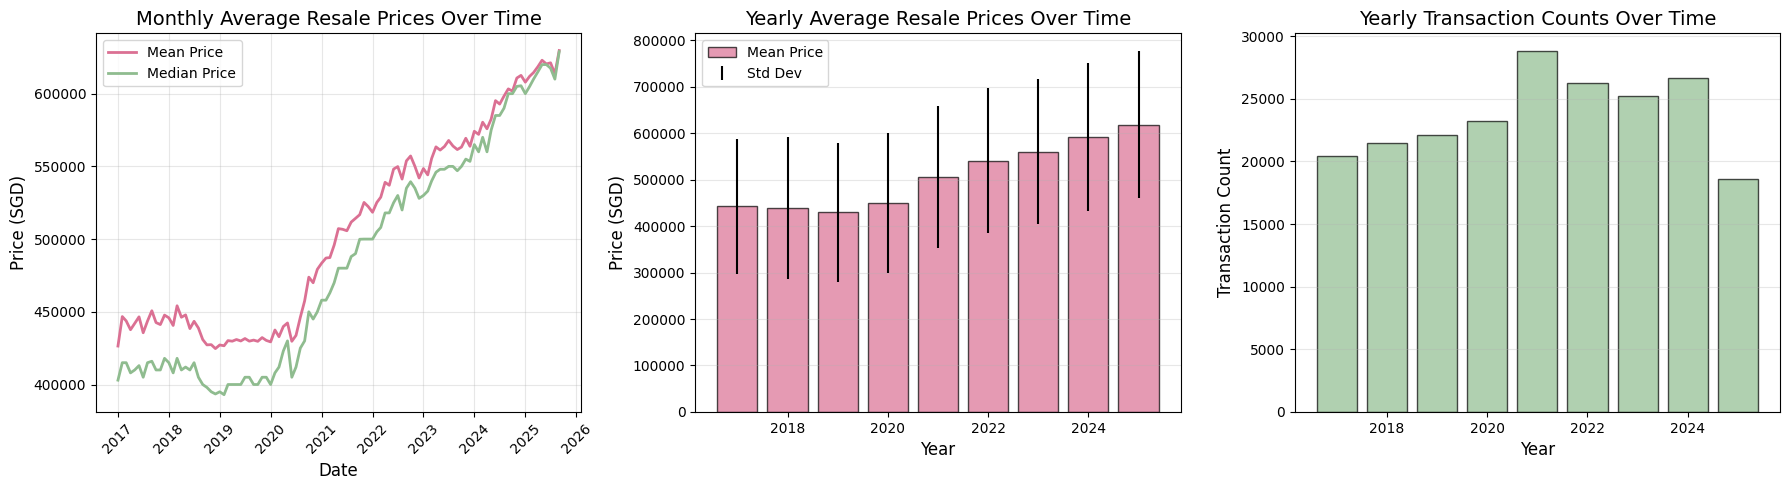

In [60]:
fig, ax =  plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Monthly Average Resale Prices Over Time
ax[0].plot(monthly_avg_prices['Date'], monthly_avg_prices['Mean_Price'],
           linewidth=2, label='Mean Price', color='palevioletred')
ax[0].plot(monthly_avg_prices['Date'], monthly_avg_prices['Median_Price'],
           linewidth=2, label='Median Price', color='darkseagreen')
ax[0].set_title('Monthly Average Resale Prices Over Time', fontsize=14)
ax[0].set_xlabel('Date', fontsize=12)
ax[0].set_ylabel('Price (SGD)', fontsize=12)
ax[0].legend(loc = 'upper left')
ax[0].grid(True, alpha=0.3)
ax[0].tick_params(axis='x', rotation=45)

# Plot 2: Yearly Average Resale Prices Over Time
ax[1].bar(yearly_avg_prices['Year'], yearly_avg_prices['Mean_Price'],
          color='palevioletred', alpha=0.7, label='Mean Price', edgecolor='black')
ax[1].errorbar(yearly_avg_prices['Year'], yearly_avg_prices['Mean_Price'],
               yerr=yearly_avg_prices['Std_Dev_Price'], fmt='none', color='black', label='Std Dev')
ax[1].set_title('Yearly Average Resale Prices Over Time', fontsize=14)
ax[1].set_xlabel('Year', fontsize=12)
ax[1].set_ylabel('Price (SGD)', fontsize=12)
ax[1].legend(loc = 'upper left')
ax[1].grid(True, alpha=0.3, axis = 'y')

# Plot 3: Yearly Transaction Counts Over Time
ax[2].bar(yearly_avg_prices['Year'], yearly_avg_prices['Transaction_Count'],
          color='darkseagreen', alpha=0.7, label='Transaction Count', edgecolor='black')
ax[2].set_title('Yearly Transaction Counts Over Time', fontsize=14)
ax[2].set_xlabel('Year', fontsize=12)
ax[2].set_ylabel('Transaction Count', fontsize=12)
ax[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


### **Analyze Feature Correlations**

From the correlation table, we can see that:
- `'Floor_Area'` is highly correlated to `'Flat_Type'`
    - For this analysis, we choose to remove `'Flat_Type'` since `'Floor_Area'` is a better representation of the amount of space in the flat. Additionally, HDB will be rolling out (['white flats'](https://www.channelnewsasia.com/singapore/hdb-new-open-concept-layout-no-walls-beams-bto-kallang-whampoa-4365806)) from October 2025. By using floor area, it would better represent the future resale of these 'white flats' that might not have the same concept of 'number of rooms' as older flats. 
- `'Price'` is highly correlated to `'Floor_Area'`, `'Year'`, `'Remaining_Lease'` and `'Storey'`
- `'Price'` is less correlated to its distance to amenities such as malls and MRT stations

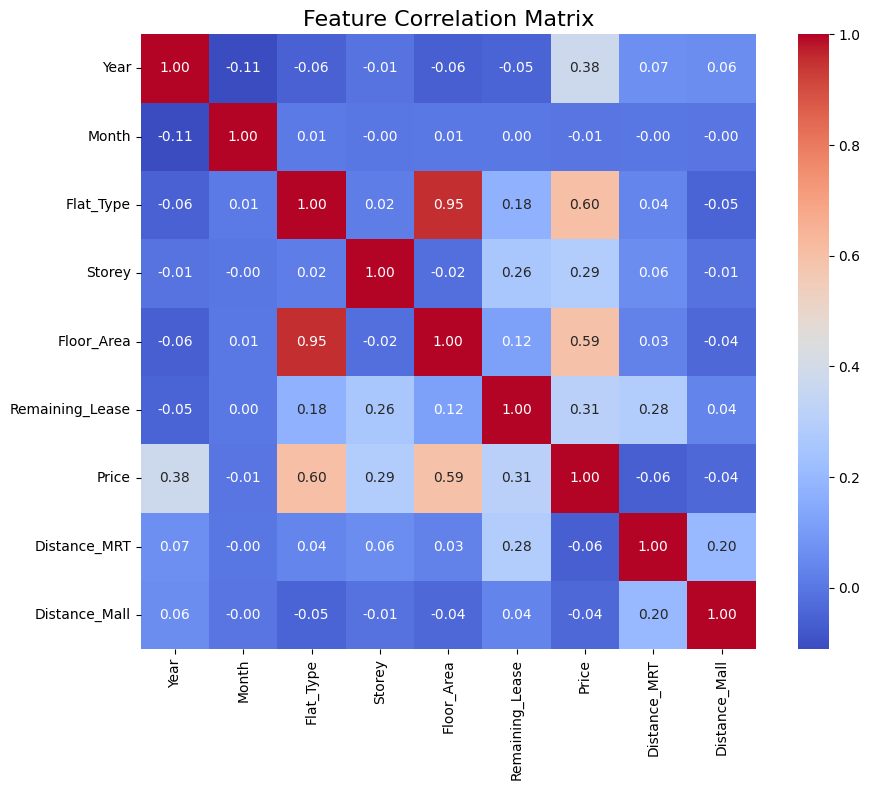

In [61]:
# Create correlation matrix for numerical features
numerical_features = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_features.corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

Year                          int64
Month                         int64
Town                         object
Flat_Type                     int64
Address                      object
Storey                        int64
Floor_Area                  float64
Remaining_Lease             float64
Price                       float64
Distance_MRT                  int64
Distance_Mall                 int64
Within_1km_of_Pri              bool
Mature                         bool
Date                 datetime64[ns]
Flat_Age                    float64
dtype: object

### **Prepare data for modelling**

In [65]:
# Encode Town using Label Encoding. Each town is assigned a unique integer.
le = LabelEncoder()
df['Town_Encoded'] = le.fit_transform(df['Town'])

# Convert boolean features to integers
df['Within_1km_of_Pri_Int'] = df['Within_1km_of_Pri'].astype(int)
df['Mature_Int'] = df['Mature'].astype(int)

# The following features will be selected for modelling:
features = [ 
    'Year', 
    'Month',
    'Storey',
    'Floor_Area',
    'Remaining_Lease',
    'Distance_MRT',
    'Distance_Mall',
    'Within_1km_of_Pri_Int',
    'Mature_Int',
    'Town_Encoded']

target = 'Price'

df1 = df[features + [target]].copy()
df1.dropna().reset_index(drop=True)


X = df1[features]
y = df1[target]

print(f"Total samples: {len(X)}")

# Split data into training and testing sets chronologically (80% train, 20% test)
train_size = int(0.8 * len(X))
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}") 
print(f"Training period: {X_train['Year'].min()}-{X_train['Month'].min()} to {X_train['Year'].max()}-{X_train['Month'].max()}")
print(f"Testing period: {X_test['Year'].min()}-{X_test['Month'].min()} to {X_test['Year'].max()}-{X_test['Month'].max()}")


Total samples: 212868
Training samples: 170294
Testing samples: 42574
Training period: 2017-1 to 2024-12
Testing period: 2024-1 to 2025-12


# **Random Forest**

In [66]:
# Training Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100,
                                 random_state=42,
                                 max_depth=30,
                                 min_samples_split=5,
                                 min_samples_leaf=2,
                                 n_jobs=-1
                                 )

rf_model.fit(X_train, y_train)
print("Random Forest model training complete.")

Random Forest model training complete.


In [67]:
# Predicting on training set
y_train_pred_rf = rf_model.predict(X_train)
# Predicting on test set
y_test_pred_rf = rf_model.predict(X_test)

# Evaluation
# Mean Absolute Error (MAE)
rf_train_mae = mean_absolute_error(y_train, y_train_pred_rf)
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)

print(f"Random Forest Training MAE: {rf_train_mae}")
print(f"Random Forest Testing MAE: {rf_test_mae}")

# Mean Squared Error (MSE)
rf_train_mse = mean_squared_error(y_train, y_train_pred_rf)
rf_test_mse = mean_squared_error(y_test, y_test_pred_rf)

print(f"Random Forest Training MSE: {rf_train_mse}")
print(f"Random Forest Testing MSE: {rf_test_mse}")

# R-squared (R2) Score
rf_train_r2 = r2_score(y_train, y_train_pred_rf)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)

print(f"Random Forest Training R2: {rf_train_r2}")
print(f"Random Forest Testing R2: {rf_test_r2}")

Random Forest Training MAE: 10477.935250281036
Random Forest Testing MAE: 52139.30499336475
Random Forest Training MSE: 232295459.096678
Random Forest Testing MSE: 4220153710.8620734
Random Forest Training R2: 0.99098581312886
Random Forest Testing R2: 0.8340742334955136
